<a href="https://colab.research.google.com/github/gracemaria321/AI-for-CyberSecurity/blob/main/LLMs%20for%20vul%20detection-%20Lab9-Part%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch datasets huggingface_hub scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load CodeBERT tokenizer & model
MODEL_NAME = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6)  # 6 vulnerability types


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
vulnerability_types = [
    "Safe Code",
    "SQL Injection",
    "Cross-Site Scripting (XSS)",
    "Command Injection",
    "Insecure Deserialization",
    "Hardcoded Credentials"
]


In [ ]:
def detect_vulnerabilities(code_snippet):
    # Tokenize input
    inputs = tokenizer(code_snippet, return_tensors="pt", truncation=True, padding=True, max_length=512)

    # Get model prediction
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()

    # Get the highest probability vulnerability type
    predicted_vulnerability = vulnerability_types[probs.index(max(probs))]

    # **Bar Chart Visualization**
    plt.figure(figsize=(8, 4))
    sns.barplot(x=vulnerability_types, y=probs, palette="coolwarm")
    plt.xticks(rotation=30, ha='right')
    plt.ylabel("Confidence Score")
    plt.title(f"Predicted Vulnerability: {predicted_vulnerability}")
    plt.ylim(0, 1)
    plt.show()

    # **Heatmap Visualization**
    plt.figure(figsize=(3, 3))
    sns.heatmap([probs], annot=True, cmap="coolwarm", xticklabels=vulnerability_types, yticklabels=["Prediction"], cbar=False)
    plt.title("Vulnerability Score Heatmap")
    plt.show()

    # Return results
    return {"Vulnerability Scores": dict(zip(vulnerability_types, probs)), "Predicted Type": predicted_vulnerability}


<ipython-input-4-5a9c96b3bb3b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vulnerability_types, y=probs, palette="coolwarm")


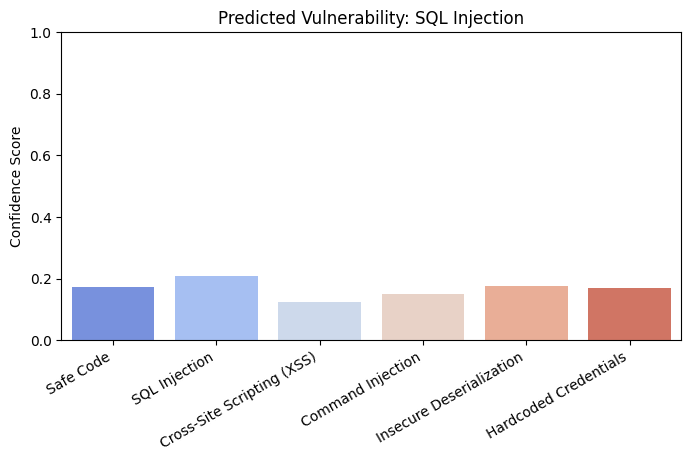

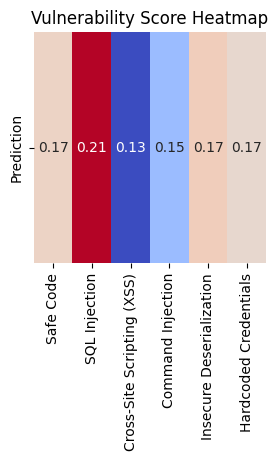

{'Vulnerability Scores': {'Safe Code': 0.17223891615867615, 'SQL Injection': 0.2088245451450348, 'Cross-Site Scripting (XSS)': 0.12500008940696716, 'Command Injection': 0.14954252541065216, 'Insecure Deserialization': 0.1742008477449417, 'Hardcoded Credentials': 0.17019298672676086}, 'Predicted Type': 'SQL Injection'}


<ipython-input-4-5a9c96b3bb3b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vulnerability_types, y=probs, palette="coolwarm")


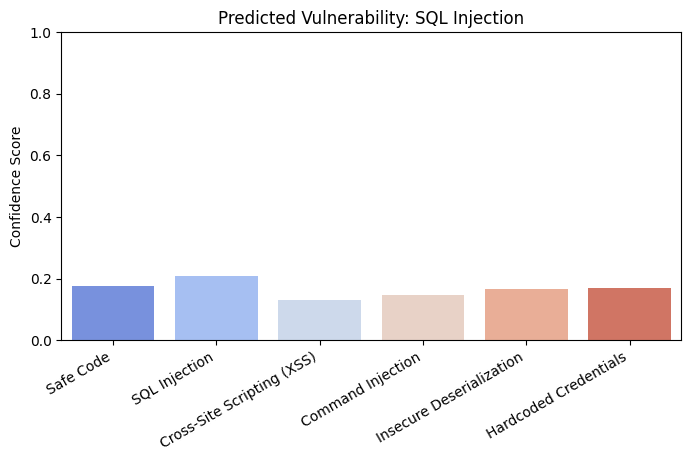

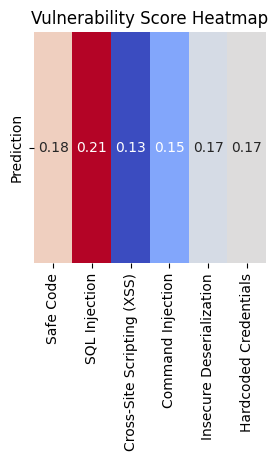

{'Vulnerability Scores': {'Safe Code': 0.17586098611354828, 'SQL Injection': 0.2092466503381729, 'Cross-Site Scripting (XSS)': 0.13001857697963715, 'Command Injection': 0.1476224660873413, 'Insecure Deserialization': 0.16733422875404358, 'Hardcoded Credentials': 0.16991710662841797}, 'Predicted Type': 'SQL Injection'}


<ipython-input-4-5a9c96b3bb3b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vulnerability_types, y=probs, palette="coolwarm")


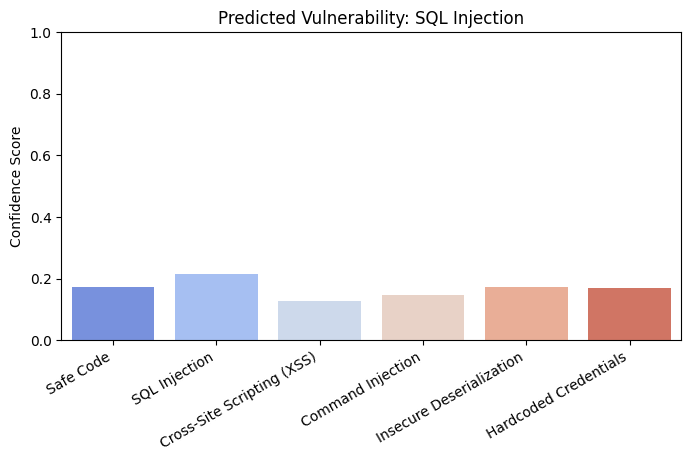

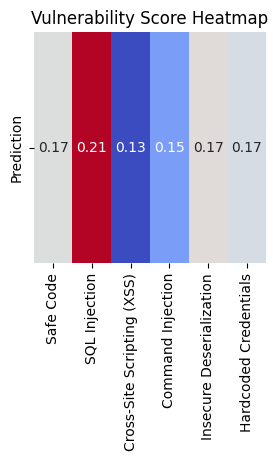

{'Vulnerability Scores': {'Safe Code': 0.17111970484256744, 'SQL Injection': 0.21432380378246307, 'Cross-Site Scripting (XSS)': 0.1281789094209671, 'Command Injection': 0.14509430527687073, 'Insecure Deserialization': 0.17227639257907867, 'Hardcoded Credentials': 0.1690068244934082}, 'Predicted Type': 'SQL Injection'}


<ipython-input-4-5a9c96b3bb3b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vulnerability_types, y=probs, palette="coolwarm")


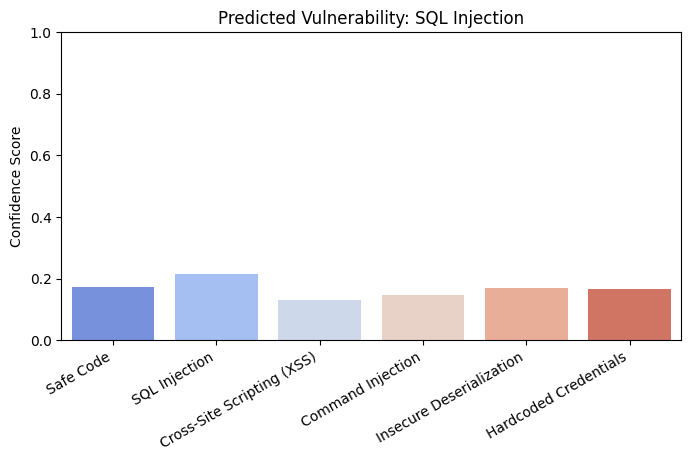

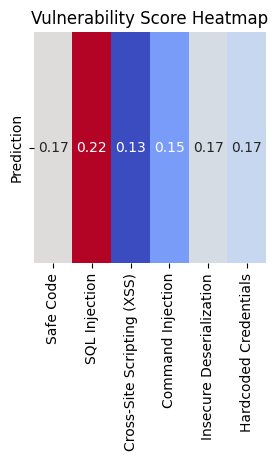

{'Vulnerability Scores': {'Safe Code': 0.17299890518188477, 'SQL Injection': 0.2152995765209198, 'Cross-Site Scripting (XSS)': 0.12953506410121918, 'Command Injection': 0.146017387509346, 'Insecure Deserialization': 0.1702197641134262, 'Hardcoded Credentials': 0.16592936217784882}, 'Predicted Type': 'SQL Injection'}


In [ ]:
# **Example 1: SQL Injection**
sql_injection_code = '''
def get_user_data(user_id):
    query = "SELECT * FROM users WHERE id = " + user_id
    execute_query(query)  # Vulnerable to SQL Injection
'''

# **Example 2: Cross-Site Scripting (XSS)**
xss_code = '''
def display_user_input(user_input):
    return "<div>" + user_input + "</div>"  # Vulnerable to XSS
'''

# **Example 3: Command Injection**
command_injection_code = '''
import os
def run_command(user_input):
    os.system("ping " + user_input)  # Command Injection Vulnerability
'''

# **Example 4: Hardcoded Credentials**
hardcoded_credentials_code = '''
def connect_to_db():
    password = "SuperSecret123"  # Hardcoded password vulnerability
'''

# **Run Detection on Each Example**
print(detect_vulnerabilities(sql_injection_code))
print(detect_vulnerabilities(xss_code))
print(detect_vulnerabilities(command_injection_code))
print(detect_vulnerabilities(hardcoded_credentials_code))
